# Onion Disease Classification — ConvNeXtTiny — Kaggle Notebook

**Dataset:** `yashraneja2/onion-dataset-combined`  
**Classes:** `molded`, `normal`, `rotten`, `sprouted`

This is a 300-epoch, imbalance-aware transfer-learning notebook using **ConvNeXtTiny**.

It includes class weights, optional focal loss, disease-preserving augmentation,
AdamW, weight decay, label smoothing, dropout, L2 regularization, gradient clipping,
validation Macro-F1, balanced accuracy, per-class precision/recall/F1,
best-checkpoint saving, ReduceLROnPlateau, duplicate/leakage checking,
confusion matrices, misclassification review, and Kaggle model export.


In [1]:

# ============================================================
# 1. Imports and reproducibility
# ============================================================
import os
import json
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Deterministic ops not enabled:", e)


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:

# ============================================================
# 2. Configuration
# ============================================================

DATASET_SLUG_DIR = Path("/kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined")

IMG_SIZE = 224
BATCH_SIZE = 24

TOTAL_EPOCHS = 300
WARMUP_EPOCHS = 30
FINE_TUNE_EPOCHS = TOTAL_EPOCHS - WARMUP_EPOCHS

INITIAL_LR = 1e-3
FINE_TUNE_LR = 2e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

USE_CLASS_WEIGHTS = True
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 1.5

USE_EARLY_STOPPING = False
EARLY_STOP_PATIENCE = 25

BEST_MODEL_PATH = "/kaggle/working/onion_convnexttiny_best_macro_f1.keras"
FINAL_MODEL_PATH = "/kaggle/working/onion_convnexttiny_final.keras"
CLASS_NAMES_PATH = "/kaggle/working/onion_convnexttiny_class_names.json"

AUTOTUNE = tf.data.AUTOTUNE


In [3]:

# ============================================================
# 3. Automatically locate train / valid / test
# ============================================================

def find_dataset_root(base_dir: Path):
    if not base_dir.exists():
        raise FileNotFoundError(
            f"{base_dir} was not found. In Kaggle, click Add Input and add "
            "'yashraneja2/onion-dataset-combined'."
        )

    candidate_names = [
        ("train", "valid", "test"),
        ("train", "val", "test"),
    ]

    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    for p in candidates:
        for train_name, val_name, test_name in candidate_names:
            if (p / train_name).is_dir() and (p / val_name).is_dir() and (p / test_name).is_dir():
                return p, train_name, val_name, test_name

    raise FileNotFoundError(
        "Could not locate train/valid/test (or train/val/test) folders under "
        f"{base_dir}."
    )

DATA_ROOT, TRAIN_NAME, VAL_NAME, TEST_NAME = find_dataset_root(DATASET_SLUG_DIR)

TRAIN_DIR = DATA_ROOT / TRAIN_NAME
VAL_DIR = DATA_ROOT / VAL_NAME
TEST_DIR = DATA_ROOT / TEST_NAME

print("Detected dataset root:", DATA_ROOT)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)


Detected dataset root: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined
Train: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/train
Validation: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/valid
Test: /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/test


,train,valid,test
molded,264,75,38
normal,708,202,101
rotten,149,43,21
sprouted,651,186,93


,train,train_share_%
molded,264,14.90
normal,708,39.95
rotten,149,8.41
sprouted,651,36.74


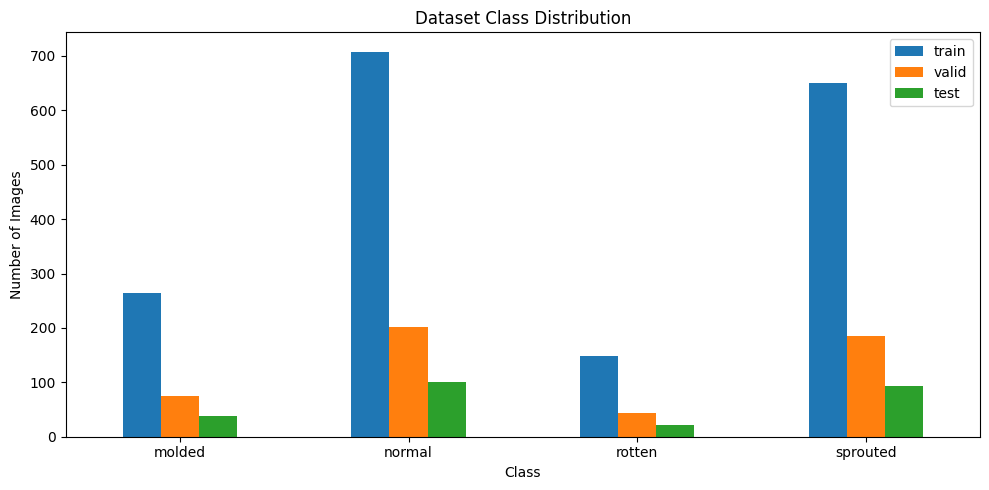

Training imbalance ratio (largest/smallest): 4.75x


In [4]:

# ============================================================
# 4. Inspect class distribution
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_by_class(folder: Path):
    result = {}
    for class_dir in sorted([p for p in folder.iterdir() if p.is_dir()]):
        count = sum(
            1 for f in class_dir.rglob("*")
            if f.is_file() and f.suffix.lower() in IMAGE_EXTS
        )
        result[class_dir.name] = count
    return result

train_counts = count_images_by_class(TRAIN_DIR)
val_counts = count_images_by_class(VAL_DIR)
test_counts = count_images_by_class(TEST_DIR)

dist_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "valid": pd.Series(val_counts),
    "test": pd.Series(test_counts),
}).fillna(0).astype(int)

display(dist_df)

total_train = dist_df["train"].sum()
dist_df["train_share_%"] = (100 * dist_df["train"] / total_train).round(2)
display(dist_df[["train", "train_share_%"]])

ax = dist_df[["train", "valid", "test"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Dataset Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

largest = dist_df["train"].max()
smallest = dist_df["train"].min()
print(f"Training imbalance ratio (largest/smallest): {largest/smallest:.2f}x")


In [5]:

# ============================================================
# 5. Duplicate / split-leakage check
# ============================================================
# Exact duplicate images across train/valid/test can inflate validation/test
# performance. This checks file-content hashes without changing the dataset.

def image_hash(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def collect_hashes(folder: Path):
    hashes = {}
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            try:
                hashes.setdefault(image_hash(p), []).append(str(p))
            except Exception as e:
                print("Hash skipped:", p, e)
    return hashes

train_hashes = collect_hashes(TRAIN_DIR)
val_hashes = collect_hashes(VAL_DIR)
test_hashes = collect_hashes(TEST_DIR)

train_set = set(train_hashes)
val_set = set(val_hashes)
test_set = set(test_hashes)

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

print("Exact duplicate hashes across splits:")
print(" train <-> valid:", len(train_val_overlap))
print(" train <-> test :", len(train_test_overlap))
print(" valid <-> test :", len(val_test_overlap))

if train_val_overlap or train_test_overlap or val_test_overlap:
    print("\nWARNING: exact duplicates were found across splits.")
    print("For a strict experiment, remove cross-split duplicates before training.")
else:
    print("\nNo exact cross-split duplicates detected.")


Exact duplicate hashes across splits:
 train <-> valid: 0
 train <-> test : 0
 valid <-> test : 0

No exact cross-split duplicates detected.


In [6]:

# ============================================================
# 6. Build TensorFlow datasets
# ============================================================

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Class order:", class_names)
print("Number of classes:", NUM_CLASSES)

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


Found 1772 files belonging to 4 classes.


I0000 00:00:1789855276.485886      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789855276.488623      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 506 files belonging to 4 classes.
Found 253 files belonging to 4 classes.
Class order: ['molded', 'normal', 'rotten', 'sprouted']
Number of classes: 4


In [7]:

# ============================================================
# 7. Class weights for imbalanced training
# ============================================================

y_for_weights = []
for idx, class_name in enumerate(class_names):
    y_for_weights.extend([idx] * int(train_counts[class_name]))

classes_array = np.arange(NUM_CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_array,
    y=np.array(y_for_weights)
)

class_weight = {i: float(w) for i, w in enumerate(weights)}

print("Balanced class weights:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name:10s} -> {class_weight[i]:.4f}")

# Normalized alpha values for optional focal loss.
alpha = np.array([class_weight[i] for i in range(NUM_CLASSES)], dtype=np.float32)
alpha = alpha / alpha.sum()

print("\nFocal-loss alpha:")
for i, name in enumerate(class_names):
    print(f"  {name:10s} -> {alpha[i]:.4f}")


Balanced class weights:
  0: molded     -> 1.6780
  1: normal     -> 0.6257
  2: rotten     -> 2.9732
  3: sprouted   -> 0.6805

Focal-loss alpha:
  molded     -> 0.2817
  normal     -> 0.1050
  rotten     -> 0.4991
  sprouted   -> 0.1142


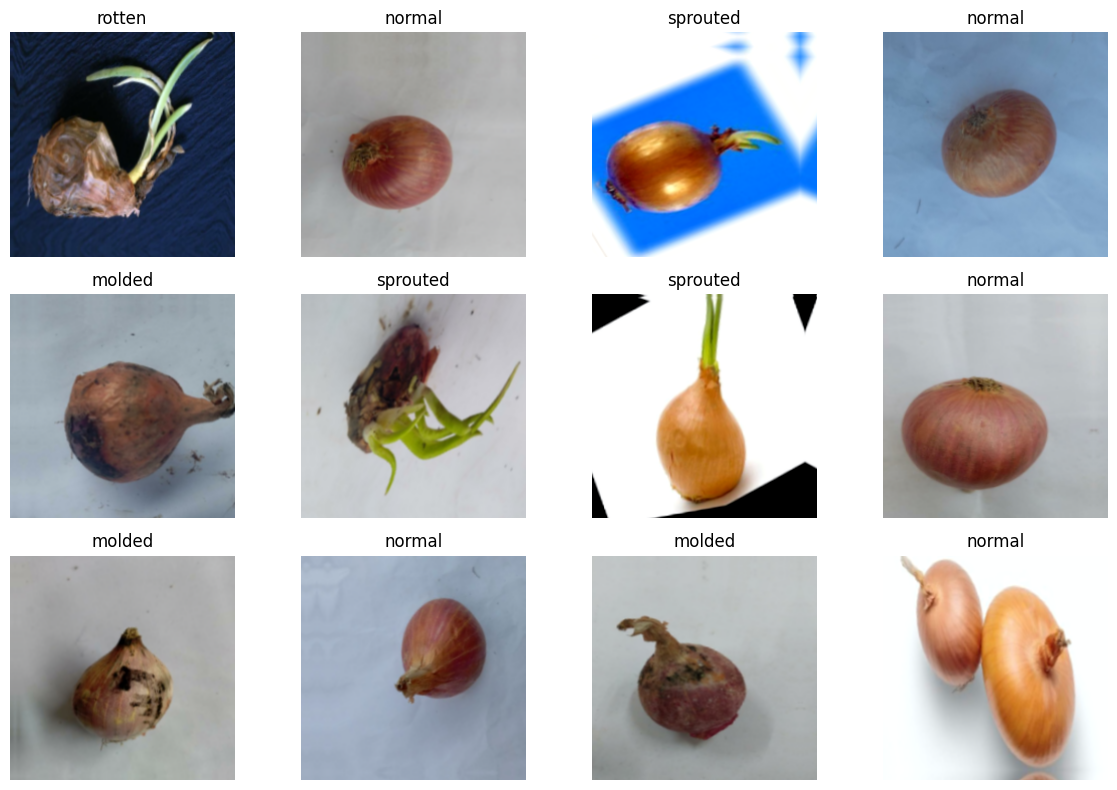

In [8]:

# ============================================================
# 8. Disease-preserving augmentation
# ============================================================
# Avoids aggressive hue/saturation transforms because discoloration can be
# diagnostically relevant for molded/rotten/sprouted onions.

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        layers.RandomRotation(0.08, fill_mode="reflect", seed=SEED),
        layers.RandomZoom(
            height_factor=(-0.12, 0.12),
            width_factor=(-0.12, 0.12),
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            fill_mode="reflect",
            seed=SEED,
        ),
        layers.RandomContrast(0.12, seed=SEED),
    ],
    name="augmentation",
)

images, labels = next(iter(train_ds.take(1)))

plt.figure(figsize=(12, 8))
for i in range(min(12, images.shape[0])):
    aug = data_augmentation(images[i:i+1], training=True)[0]
    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(aug, 0, 255), tf.uint8))
    plt.title(class_names[int(tf.argmax(labels[i]))])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [9]:

# ============================================================
# 9. Optional focal loss
# ============================================================
# Default: class-weighted categorical cross-entropy.
# For a second experiment, set USE_FOCAL_LOSS=True.

if USE_FOCAL_LOSS:
    if not hasattr(keras.losses, "CategoricalFocalCrossentropy"):
        raise RuntimeError(
            "CategoricalFocalCrossentropy is unavailable in this Kaggle image. "
            "Set USE_FOCAL_LOSS=False."
        )
    loss_fn = keras.losses.CategoricalFocalCrossentropy(
        alpha=alpha.tolist(),
        gamma=FOCAL_GAMMA,
        label_smoothing=LABEL_SMOOTHING,
    )
    fit_class_weight = None
    print("Using categorical focal loss.")
else:
    loss_fn = keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
    fit_class_weight = class_weight if USE_CLASS_WEIGHTS else None
    print("Using categorical cross-entropy.")
    print("Class weights enabled:", USE_CLASS_WEIGHTS)


Using categorical cross-entropy.
Class weights enabled: True


In [10]:

# ============================================================
# 10. Build ConvNeXtTiny transfer-learning model
# ============================================================

keras.backend.clear_session()

base_model = keras.applications.ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg",
    include_preprocessing=True,
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.BatchNormalization(name="head_bn")(x)
x = layers.Dropout(0.40, name="head_dropout_1")(x)
x = layers.Dense(
    256, activation="gelu",
    kernel_regularizer=regularizers.l2(1e-4),
    name="head_dense",
)(x)
x = layers.Dropout(0.25, name="head_dropout_2")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = keras.Model(inputs, outputs, name="onion_convnexttiny")
model.summary()


111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "onion_convnexttiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 768)            │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 768)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,021,092 (106.89 MB)

 Trainable params: 199,428 (779.02 KB)

 Non-trainable params: 27,821,664 (106.13 MB)

In [11]:

# ============================================================
# 11. Imbalance-aware validation callback
# ============================================================
# Computes validation Macro-F1, balanced accuracy, and every class recall at
# the end of each epoch. These metrics are more informative than accuracy
# alone on an imbalanced dataset.

class ImbalanceMetricsCallback(keras.callbacks.Callback):
    def __init__(self, dataset, class_names, prefix="val"):
        super().__init__()
        self.dataset = dataset
        self.class_names = class_names
        self.prefix = prefix

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}

        y_true = []
        y_prob = []

        for batch_images, batch_labels in self.dataset:
            probs = self.model.predict(batch_images, verbose=0)
            y_prob.append(probs)
            y_true.append(np.argmax(batch_labels.numpy(), axis=1))

        y_true = np.concatenate(y_true)
        y_prob = np.concatenate(y_prob)
        y_pred = np.argmax(y_prob, axis=1)

        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        per_class_precision = precision_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )
        per_class_recall = recall_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )
        per_class_f1 = f1_score(
            y_true, y_pred, average=None,
            labels=np.arange(len(self.class_names)),
            zero_division=0
        )

        logs[f"{self.prefix}_macro_f1"] = macro_f1
        logs[f"{self.prefix}_balanced_accuracy"] = bal_acc

        parts = [
            f"{self.prefix}_macro_f1={macro_f1:.4f}",
            f"{self.prefix}_balanced_acc={bal_acc:.4f}"
        ]

        for i, name in enumerate(self.class_names):
            safe = name.lower().replace(" ", "_")
            logs[f"{self.prefix}_{safe}_precision"] = per_class_precision[i]
            logs[f"{self.prefix}_{safe}_recall"] = per_class_recall[i]
            logs[f"{self.prefix}_{safe}_f1"] = per_class_f1[i]
            parts.append(f"{name}_recall={per_class_recall[i]:.3f}")

        print("\n" + " | ".join(parts))


In [12]:

# ============================================================
# 12. Metrics, optimizer, callbacks
# ============================================================

metrics = [
    keras.metrics.CategoricalAccuracy(name="accuracy"),
    keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
]

def make_callbacks(stage_name):
    imbalance_metrics = ImbalanceMetricsCallback(
        val_ds,
        class_names,
        prefix="val"
    )

    callbacks = [
        # Must run BEFORE ModelCheckpoint so val_macro_f1 is available.
        imbalance_metrics,

        keras.callbacks.ModelCheckpoint(
            BEST_MODEL_PATH,
            monitor="val_macro_f1",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_macro_f1",
            mode="max",
            factor=0.25,
            patience=8,
            min_lr=1e-7,
            verbose=1,
        ),

        keras.callbacks.CSVLogger(
            f"/kaggle/working/{stage_name}_training_log.csv",
            append=False,
        ),

        keras.callbacks.TerminateOnNaN(),
    ]

    if USE_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_macro_f1",
                mode="max",
                patience=EARLY_STOP_PATIENCE,
                restore_best_weights=True,
                verbose=1,
            )
        )

    return callbacks


In [13]:

# ============================================================
# 13. Phase 1 — frozen-backbone warm-up
# ============================================================

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=INITIAL_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    class_weight=fit_class_weight,
    callbacks=make_callbacks("phase1"),
    verbose=1,
)


Epoch 1/30


I0000 00:00:1789855294.734460      78 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.6839 - loss: 1.1382 - top2_accuracy: 0.8653

2026-09-19 22:02:05.629841: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-19 22:02:10.631875: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


val_macro_f1=0.8864 | val_balanced_acc=0.8684 | molded_recall=0.827 | normal_recall=0.985 | rotten_recall=0.721 | sprouted_recall=0.941

Epoch 1: val_macro_f1 improved from None to 0.88637, saving model to /kaggle/working/onion_convnexttiny_best_macro_f1.keras

Epoch 1: finished saving model to /kaggle/working/onion_convnexttiny_best_macro_f1.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 578ms/step - accuracy: 0.8222 - loss: 0.8052 - top2_accuracy: 0.9368 - val_accuracy: 0.9229 - val_loss: 0.4404 - val_top2_accuracy: 0.9743 - val_macro_f1: 0.8864 - val_balanced_accuracy: 0.8684 - val_molded_precision: 0.8493 - val_molded_recall: 0.8267 - val_molded_f1: 0.8378 - val_normal_precision: 0.9005 - val_normal_recall: 0.9851 - val_normal_f1: 0.9409 - val_rotten_precision: 0.9118 - val_rotten_recall: 0.7209 - val_rotten_f1: 0.8052 - val_sprouted_precision: 0.9831 - val_sprouted_recall: 0.9409 - val_sprouted_f1: 0.9615 - learning_rate: 0.0010
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accurac

...


val_macro_f1=0.9435 | val_balanced_acc=0.9446 | molded_recall=0.960 | normal_recall=0.990 | rotten_recall=0.860 | sprouted_recall=0.968

Epoch 28: val_macro_f1 did not improve from 0.95399
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 404ms/step - accuracy: 0.9887 - loss: 0.3114 - top2_accuracy: 0.9989 - val_accuracy: 0.9664 - val_loss: 0.3755 - val_top2_accuracy: 0.9901 - val_macro_f1: 0.9435 - val_balanced_accuracy: 0.9446 - val_molded_precision: 0.8675 - val_molded_recall: 0.9600 - val_molded_f1: 0.9114 - val_normal_precision: 0.9901 - val_normal_recall: 0.9901 - val_normal_f1: 0.9901 - val_rotten_precision: 0.9250 - val_rotten_recall: 0.8605 - val_rotten_f1: 0.8916 - val_sprouted_precision: 0.9945 - val_sprouted_recall: 0.9677 - val_sprouted_f1: 0.9809 - learning_rate: 2.5000e-04
Epoch 29/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9880 - loss: 0.3145 - top2_accuracy: 0.9979

2026-09-19 22:16:09.935107: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-19 22:16:15.031810: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


val_macro_f1=0.9542 | val_balanced_acc=0.9562 | molded_recall=0.960 | normal_recall=0.990 | rotten_recall=0.907 | sprouted_recall=0.968

Epoch 29: val_macro_f1 improved from 0.95399 to 0.95420, saving model to /kaggle/working/onion_convnexttiny_best_macro_f1.keras

Epoch 29: finished saving model to /kaggle/working/onion_convnexttiny_best_macro_f1.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 415ms/step - accuracy: 0.9870 - loss: 0.3165 - top2_accuracy: 0.9983 - val_accuracy: 0.9704 - val_loss: 0.3621 - val_top2_accuracy: 0.9901 - val_macro_f1: 0.9542 - val_balanced_accuracy: 0.9562 - val_molded_precision: 0.8780 - val_molded_recall: 0.9600 - val_molded_f1: 0.9172 - val_normal_precision: 0.9901 - val_normal_recall: 0.9901 - val_normal_f1: 0.9901 - val_rotten_precision: 0.9512 - val_rotten_recall: 0.9070 - val_rotten_f1: 0.9286 - val_sprouted_precision: 0.9945 - val_sprouted_recall: 0.9677 - val_sprouted_f1: 0.9809 - learning_rate: 2.5000e-04
Epoch 30/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step

2026-09-19 22:16:40.494088: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-19 22:16:45.575405: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


val_macro_f1=0.9542 | val_balanced_acc=0.9562 | molded_recall=0.960 | normal_recall=0.990 | rotten_recall=0.907 | sprouted_recall=0.968

Epoch 30: val_macro_f1 did not improve from 0.95420
74/74 ━━━━━━━━━━━━━━━━━━━━ 30s 404ms/step - accuracy: 0.9865 - loss: 0.3170 - top2_accuracy: 0.9989 - val_accuracy: 0.9704 - val_loss: 0.3671 - val_top2_accuracy: 0.9921 - val_macro_f1: 0.9542 - val_balanced_accuracy: 0.9562 - val_molded_precision: 0.8780 - val_molded_recall: 0.9600 - val_molded_f1: 0.9172 - val_normal_precision: 0.9901 - val_normal_recall: 0.9901 - val_normal_f1: 0.9901 - val_rotten_precision: 0.9512 - val_rotten_recall: 0.9070 - val_rotten_f1: 0.9286 - val_sprouted_precision: 0.9945 - val_sprouted_recall: 0.9677 - val_sprouted_f1: 0.9809 - learning_rate: 2.5000e-04


In [14]:

# ============================================================
# 14. Phase 2 — fine-tune backbone
# ============================================================

base_model.trainable = True

# Freeze BatchNorm layers during fine-tuning for stability on a small dataset.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f"Trainable backbone layers: {trainable_count}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=FINE_TUNE_LR,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    ),
    loss=loss_fn,
    metrics=metrics,
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=WARMUP_EPOCHS,
    epochs=TOTAL_EPOCHS,
    class_weight=fit_class_weight,
    callbacks=make_callbacks("phase2"),
    verbose=1,
)


Trainable backbone layers: 134/134
Epoch 31/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9812 - loss: 0.3158 - top2_accuracy: 0.9964

2026-09-19 22:18:54.708370: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-19 22:18:59.820492: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


val_macro_f1=0.9609 | val_balanced_acc=0.9622 | molded_recall=0.973 | normal_recall=0.990 | rotten_recall=0.907 | sprouted_recall=0.978

Epoch 31: val_macro_f1 improved from None to 0.96087, saving model to /kaggle/working/onion_convnexttiny_best_macro_f1.keras

Epoch 31: finished saving model to /kaggle/working/onion_convnexttiny_best_macro_f1.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9855 - loss: 0.3149 - top2_accuracy: 0.9978 - val_accuracy: 0.9763 - val_loss: 0.3559 - val_top2_accuracy: 0.9941 - val_macro_f1: 0.9609 - val_balanced_accuracy: 0.9622 - val_molded_precision: 0.9012 - val_molded_recall: 0.9733 - val_molded_f1: 0.9359 - val_normal_precision: 0.9950 - val_normal_recall: 0.9901 - val_normal_f1: 0.9926 - val_rotten_precision: 0.9512 - val_rotten_recall: 0.9070 - val_rotten_f1: 0.9286 - val_sprouted_precision: 0.9945 - val_sprouted_recall: 0.9785 - val_sprouted_f1: 0.9864 - learning_rate: 2.0000e-05
Epoch 32/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accu

2026-09-19 22:20:29.531321: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-19 22:20:34.576269: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


val_macro_f1=0.9514 | val_balanced_acc=0.9524 | molded_recall=0.973 | normal_recall=0.990 | rotten_recall=0.884 | sprouted_recall=0.962

Epoch 32: val_macro_f1 did not improve from 0.96087
74/74 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9904 - loss: 0.3070 - top2_accuracy: 0.9983 - val_accuracy: 0.9684 - val_loss: 0.3459 - val_top2_accuracy: 0.9941 - val_macro_f1: 0.9514 - val_balanced_accuracy: 0.9524 - val_molded_precision: 0.8795 - val_molded_recall: 0.9733 - val_molded_f1: 0.9241 - val_normal_precision: 0.9852 - val_normal_recall: 0.9901 - val_normal_f1: 0.9877 - val_rotten_precision: 0.9500 - val_rotten_recall: 0.8837 - val_rotten_f1: 0.9157 - val_sprouted_precision: 0.9944 - val_sprouted_recall: 0.9624 - val_sprouted_f1: 0.9781 - learning_rate: 2.0000e-05
Epoch 33/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9880 - loss: 0.3064 - top2_accuracy: 0.9983

...


val_macro_f1=0.9664 | val_balanced_acc=0.9679 | molded_recall=0.973 | normal_recall=0.995 | rotten_recall=0.930 | sprouted_recall=0.973

Epoch 298: val_macro_f1 did not improve from 0.96638
74/74 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9989 - loss: 0.2756 - top2_accuracy: 1.0000 - val_accuracy: 0.9783 - val_loss: 0.3213 - val_top2_accuracy: 0.9941 - val_macro_f1: 0.9664 - val_balanced_accuracy: 0.9679 - val_molded_precision: 0.9241 - val_molded_recall: 0.9733 - val_molded_f1: 0.9481 - val_normal_precision: 0.9901 - val_normal_recall: 0.9950 - val_normal_f1: 0.9926 - val_rotten_precision: 0.9524 - val_rotten_recall: 0.9302 - val_rotten_f1: 0.9412 - val_sprouted_precision: 0.9945 - val_sprouted_recall: 0.9731 - val_sprouted_f1: 0.9837 - learning_rate: 1.0000e-07
Epoch 299/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9969 - loss: 0.2778 - top2_accuracy: 1.0000

2026-09-20 04:43:36.221441: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-20 04:43:41.350122: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


val_macro_f1=0.9664 | val_balanced_acc=0.9679 | molded_recall=0.973 | normal_recall=0.995 | rotten_recall=0.930 | sprouted_recall=0.973

Epoch 299: val_macro_f1 did not improve from 0.96638
74/74 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9989 - loss: 0.2753 - top2_accuracy: 1.0000 - val_accuracy: 0.9783 - val_loss: 0.3213 - val_top2_accuracy: 0.9941 - val_macro_f1: 0.9664 - val_balanced_accuracy: 0.9679 - val_molded_precision: 0.9241 - val_molded_recall: 0.9733 - val_molded_f1: 0.9481 - val_normal_precision: 0.9901 - val_normal_recall: 0.9950 - val_normal_f1: 0.9926 - val_rotten_precision: 0.9524 - val_rotten_recall: 0.9302 - val_rotten_f1: 0.9412 - val_sprouted_precision: 0.9945 - val_sprouted_recall: 0.9731 - val_sprouted_f1: 0.9837 - learning_rate: 1.0000e-07
Epoch 300/300
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9992 - loss: 0.2723 - top2_accuracy: 1.0000

2026-09-20 04:45:02.283846: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-20 04:45:07.384482: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


val_macro_f1=0.9664 | val_balanced_acc=0.9679 | molded_recall=0.973 | normal_recall=0.995 | rotten_recall=0.930 | sprouted_recall=0.973

Epoch 300: val_macro_f1 did not improve from 0.96638
74/74 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9994 - loss: 0.2768 - top2_accuracy: 1.0000 - val_accuracy: 0.9783 - val_loss: 0.3213 - val_top2_accuracy: 0.9941 - val_macro_f1: 0.9664 - val_balanced_accuracy: 0.9679 - val_molded_precision: 0.9241 - val_molded_recall: 0.9733 - val_molded_f1: 0.9481 - val_normal_precision: 0.9901 - val_normal_recall: 0.9950 - val_normal_f1: 0.9926 - val_rotten_precision: 0.9524 - val_rotten_recall: 0.9302 - val_rotten_f1: 0.9412 - val_sprouted_precision: 0.9945 - val_sprouted_recall: 0.9731 - val_sprouted_f1: 0.9837 - learning_rate: 1.0000e-07


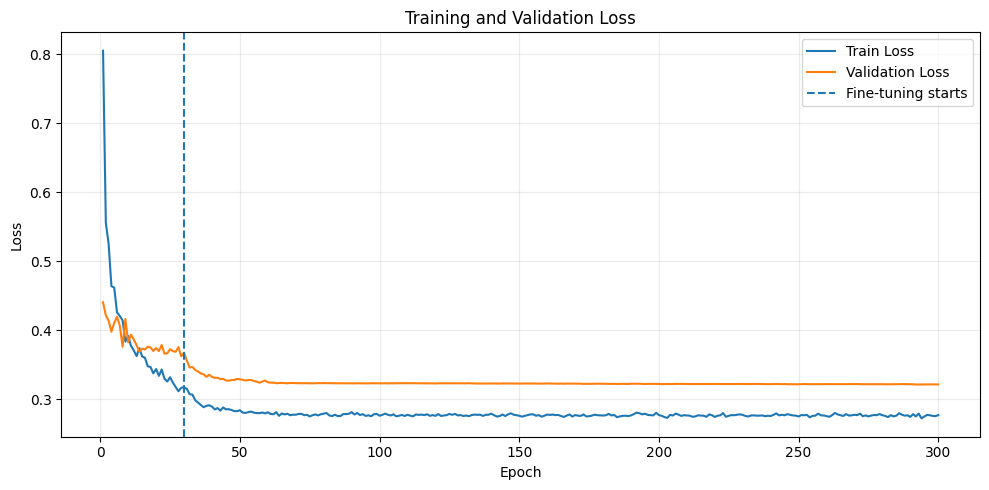

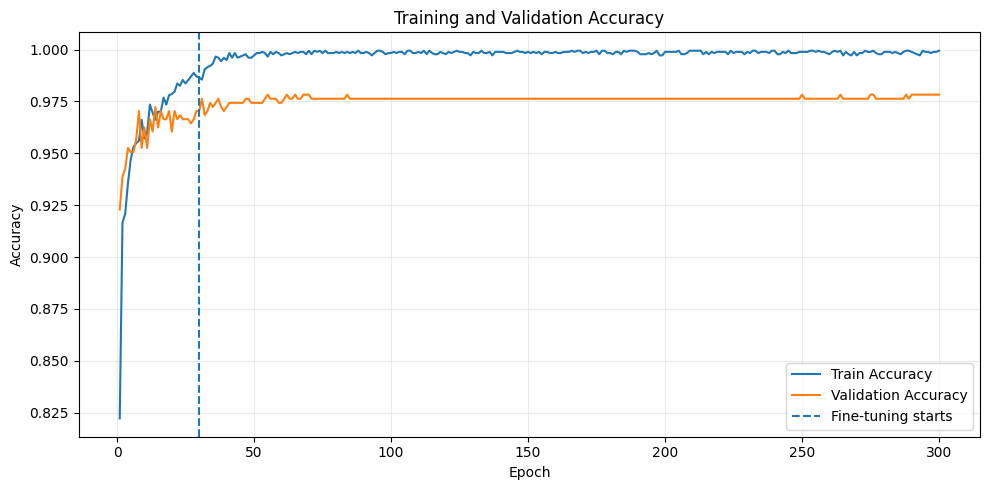

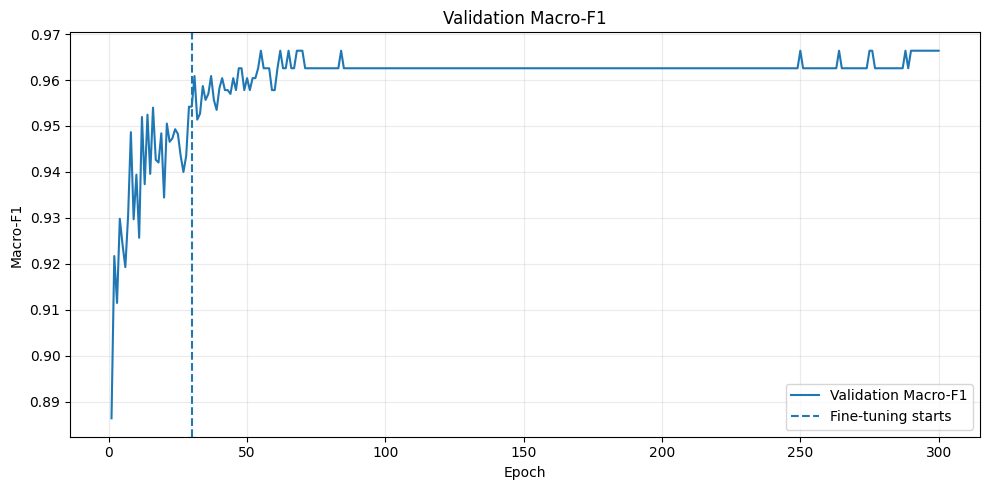

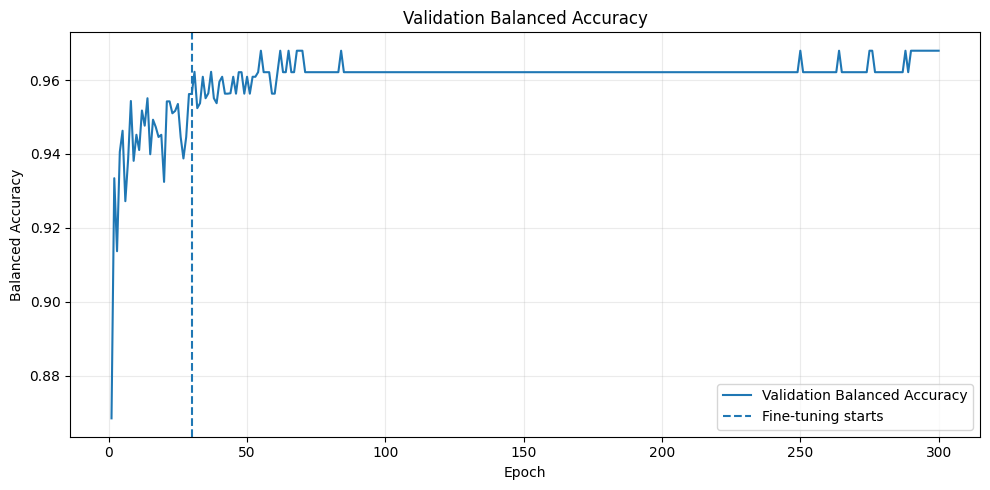

In [15]:

# ============================================================
# 15. Plot training history
# ============================================================

def merge_histories(h1, h2):
    merged = {}
    keys = set(h1.history.keys()) | set(h2.history.keys())
    for key in keys:
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return merged

history = merge_histories(history_warmup, history_finetune)
epochs_ran = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["accuracy"], label="Train Accuracy")
plt.plot(epochs_ran, history["val_accuracy"], label="Validation Accuracy")
plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

if "val_macro_f1" in history:
    plt.figure(figsize=(10, 5))
    plt.plot(epochs_ran, history["val_macro_f1"], label="Validation Macro-F1")
    plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title("Validation Macro-F1")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

if "val_balanced_accuracy" in history:
    plt.figure(figsize=(10, 5))
    plt.plot(
        epochs_ran,
        history["val_balanced_accuracy"],
        label="Validation Balanced Accuracy"
    )
    plt.axvline(WARMUP_EPOCHS, linestyle="--", label="Fine-tuning starts")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced Accuracy")
    plt.title("Validation Balanced Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 423ms/step - accuracy: 0.9921 - loss: 0.1223 - top2_accuracy: 0.9921

Best-checkpoint test metrics:
accuracy: 0.99209
loss: 0.12232
top2_accuracy: 0.99209


2026-09-20 04:45:23.430967: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-09-20 04:45:28.729943: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Test Macro-F1:          0.9860
Test Weighted-F1:       0.9923
Test Balanced Accuracy: 0.9948

Classification Report:
              precision    recall  f1-score   support

      molded     1.0000    1.0000    1.0000        38
      normal     1.0000    0.9901    0.9950       101
      rotten     0.9130    1.0000    0.9545        21
    sprouted     1.0000    0.9892    0.9946        93

    accuracy                         0.9921       253
   macro avg     0.9783    0.9948    0.9860       253
weighted avg     0.9928    0.9921    0.9923       253



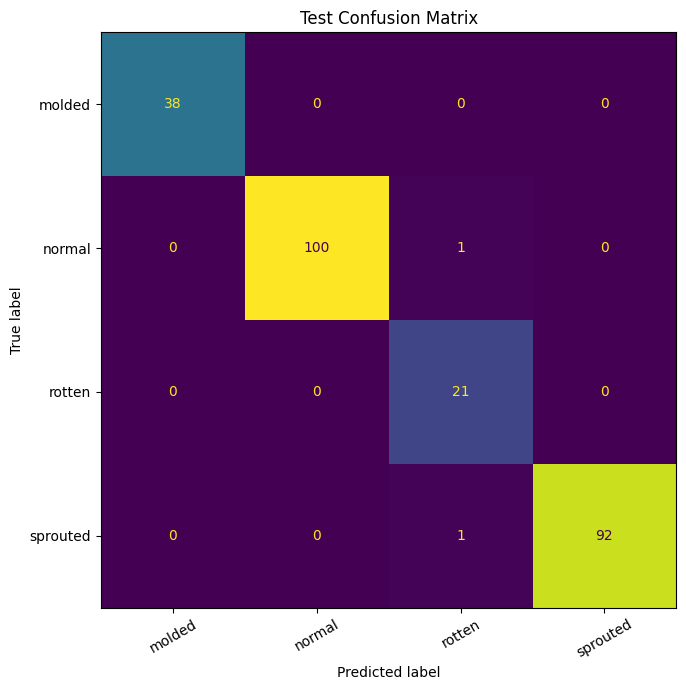

In [16]:

# ============================================================
# 16. Test-set evaluation using BEST Macro-F1 checkpoint
# ============================================================

# compile=False makes loading robust even if the training run used focal loss.
best_model = keras.models.load_model(BEST_MODEL_PATH, compile=False)
best_model.compile(
    optimizer="adam",
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_accuracy"),
    ],
)

test_results = best_model.evaluate(test_ds, verbose=1, return_dict=True)

print("\nBest-checkpoint test metrics:")
for k, v in test_results.items():
    print(f"{k}: {v:.5f}")

y_true = []
y_prob = []

for batch_images, batch_labels in test_ds:
    probs = best_model.predict(batch_images, verbose=0)
    y_prob.append(probs)
    y_true.append(np.argmax(batch_labels.numpy(), axis=1))

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)
y_pred = np.argmax(y_prob, axis=1)

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"\nTest Macro-F1:          {macro_f1:.4f}")
print(f"Test Weighted-F1:       {weighted_f1:.4f}")
print(f"Test Balanced Accuracy: {bal_acc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, values_format="d", colorbar=False
)
plt.title("Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [17]:

# ============================================================
# 17. Per-class precision / recall / F1 table
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

per_class_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df["support"] = per_class_df["support"].astype(int)

print("\nPer-class test performance:")
display(per_class_df)

# Minority-class warning
train_series = pd.Series(train_counts).reindex(class_names)
minority_classes = train_series.sort_values().index[:2].tolist()

print("Minority classes by training count:", minority_classes)
for c in minority_classes:
    rec = float(per_class_df.loc[c, "recall"])
    if rec < 0.75:
        print(
            f"WARNING: {c} recall is {rec:.3f}. "
            "Consider enabling USE_FOCAL_LOSS=True and retraining."
        )

report_df.to_csv("/kaggle/working/test_classification_report.csv")
per_class_df.to_csv("/kaggle/working/test_per_class_metrics.csv")


,precision,recall,f1-score,support
molded,1.000000,1.000000,1.000000,38.000000
normal,1.000000,0.990099,0.995025,101.000000
rotten,0.913043,1.000000,0.954545,21.000000
sprouted,1.000000,0.989247,0.994595,93.000000
accuracy,0.992095,0.992095,0.992095,0.992095
macro avg,0.978261,0.994837,0.986041,253.000000
weighted avg,0.992782,0.992095,0.992254,253.000000



Per-class test performance:


,precision,recall,f1-score,support
molded,1.000000,1.000000,1.000000,38
normal,1.000000,0.990099,0.995025,101
rotten,0.913043,1.000000,0.954545,21
sprouted,1.000000,0.989247,0.994595,93


Minority classes by training count: ['rotten', 'molded']


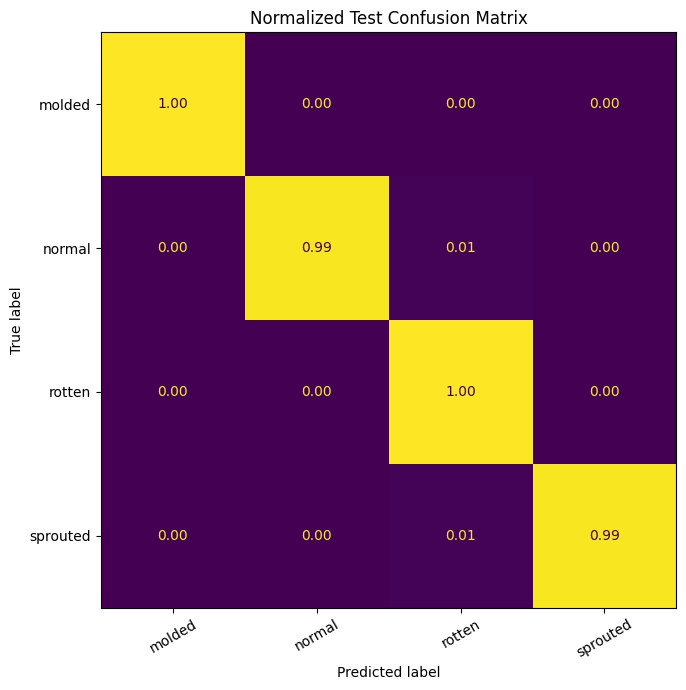

In [18]:

# ============================================================
# 18. Normalized confusion matrix
# ============================================================

cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)
disp.plot(ax=ax, values_format=".2f", colorbar=False)
plt.title("Normalized Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Misclassified test images: 2


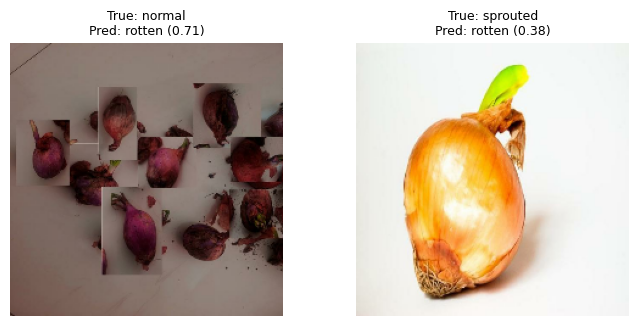

In [19]:

# ============================================================
# 19. Inspect misclassified test images
# ============================================================

misclassified = np.where(y_true != y_pred)[0]
print("Misclassified test images:", len(misclassified))

if len(misclassified) > 0:
    test_images_np = np.concatenate(
        [x.numpy().astype(np.uint8) for x, _ in test_ds],
        axis=0
    )

    # Show highest-confidence mistakes first.
    wrong_conf = np.max(y_prob[misclassified], axis=1)
    order = np.argsort(-wrong_conf)
    selected = misclassified[order[: min(16, len(misclassified))]]

    plt.figure(figsize=(14, 12))
    for plot_idx, data_idx in enumerate(selected):
        plt.subplot(4, 4, plot_idx + 1)
        plt.imshow(test_images_np[data_idx])
        confidence = float(np.max(y_prob[data_idx]))
        plt.title(
            f"True: {class_names[y_true[data_idx]]}\n"
            f"Pred: {class_names[y_pred[data_idx]]} ({confidence:.2f})",
            fontsize=9,
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found.")


In [20]:

# ============================================================
# 20. Save final model and metadata
# ============================================================

# Save final epoch model separately from best validation Macro-F1 model.
model.save(FINAL_MODEL_PATH)

metadata = {
    "model": "ConvNeXtTiny",
    "image_size": IMG_SIZE,
    "classes": class_names,
    "train_counts": train_counts,
    "valid_counts": val_counts,
    "test_counts": test_counts,
    "class_weight": class_weight,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "use_focal_loss": USE_FOCAL_LOSS,
    "focal_gamma": FOCAL_GAMMA,
    "total_epochs_configured": TOTAL_EPOCHS,
    "warmup_epochs": WARMUP_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "label_smoothing": LABEL_SMOOTHING,
    "weight_decay": WEIGHT_DECAY,
    "checkpoint_monitor": "val_macro_f1",
    "test_macro_f1": float(macro_f1),
    "test_weighted_f1": float(weighted_f1),
    "test_balanced_accuracy": float(bal_acc),
    "best_model_path": BEST_MODEL_PATH,
    "final_model_path": FINAL_MODEL_PATH,
}

with open("/kaggle/working/onion_convnexttiny_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print(" ", BEST_MODEL_PATH)
print(" ", FINAL_MODEL_PATH)
print(" ", CLASS_NAMES_PATH)
print(" ", "/kaggle/working/onion_convnexttiny_metadata.json")
print(" ", "/kaggle/working/test_classification_report.csv")
print(" ", "/kaggle/working/test_per_class_metrics.csv")


Saved:
  /kaggle/working/onion_convnexttiny_best_macro_f1.keras
  /kaggle/working/onion_convnexttiny_final.keras
  /kaggle/working/onion_convnexttiny_class_names.json
  /kaggle/working/onion_convnexttiny_metadata.json
  /kaggle/working/test_classification_report.csv
  /kaggle/working/test_per_class_metrics.csv


In [21]:

# ============================================================
# 21. Single-image inference helper
# ============================================================

def predict_onion_image(image_path, trained_model=best_model):
    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
    )
    arr = keras.utils.img_to_array(img)
    arr = tf.expand_dims(arr, axis=0)

    probs = trained_model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    return {
        "predicted_class": class_names[pred_idx],
        "confidence": float(probs[pred_idx]),
        "probabilities": {
            class_names[i]: float(probs[i])
            for i in range(NUM_CLASSES)
        },
    }

# Example:
# print(predict_onion_image("/kaggle/input/your-image-folder/example.jpg"))



## What was added specifically for the class imbalance

1. **Balanced class weights** so minority-class errors matter more during training.
2. **Macro-F1** as the primary validation checkpoint metric rather than plain accuracy.
3. **Balanced accuracy** monitoring.
4. **Per-class precision, recall, and F1** so `rotten` and `molded` performance cannot be hidden by strong majority-class accuracy.
5. **Normalized confusion matrix** for class-by-class error analysis.
6. **Optional focal loss** for a second training run if minority-class recall remains weak.
7. **Disease-preserving augmentation** that avoids heavy color distortion.
8. **Duplicate/leakage check** across train/valid/test splits.
9. **Highest-confidence misclassification review** to identify labeling or visual ambiguity problems.

### Recommended workflow

Run the notebook first with:

```python
USE_FOCAL_LOSS = False
USE_CLASS_WEIGHTS = True
```

This is the safer baseline.

After training, inspect `rotten` and `molded` recall. If either is still clearly weak, make a second Kaggle run with:

```python
USE_FOCAL_LOSS = True
```

When focal loss is enabled, the notebook automatically disables `class_weight` during `fit()` so the minority classes are not accidentally weighted twice.

### Kaggle settings
- Accelerator: **GPU**
- Run all cells in order
- The best model is selected by **validation Macro-F1**, not the final epoch
- The final model and best model are both saved under `/kaggle/working/`


### Model in this notebook
**ConvNeXtTiny**

Keep the train/valid/test split unchanged when comparing this notebook with the other models.
Choose the final model using **test Macro-F1, balanced accuracy, and minority-class recall/F1**,
not training accuracy alone.
